In [35]:
import matplotlib.pyplot as plt
import pandas as pd

# Simple dataset for K-Medoids and Hierarchical Clustering
df = pd.DataFrame({
    "Age": [22, 25, 23, 45, 47, 43, 31, 33, 30, 52],
    "Income": [2000, 2200, 2100, 8000, 8500, 7800, 4500, 4700, 4300, 9000],
    "Spending_Score": [80, 75, 78, 20, 18, 25, 55, 50, 58, 15]
})

print(df)

   Age  Income  Spending_Score
0   22    2000              80
1   25    2200              75
2   23    2100              78
3   45    8000              20
4   47    8500              18
5   43    7800              25
6   31    4500              55
7   33    4700              50
8   30    4300              58
9   52    9000              15


In [36]:
x = df[["Income","Spending_Score"]]

In [37]:
from sklearn_extra.cluster import KMedoids

In [38]:
km = KMedoids(n_clusters=3,metric="manhattan",init='random')

In [39]:
km.fit(x)

KMedoids(init='random', metric='manhattan', n_clusters=3)

In [40]:
labels = km.labels_

In [41]:
df = pd.concat(
    [df,pd.Series(labels,name="cluster")],
    axis=1
)

In [42]:
df

,Age,Income,Spending_Score,cluster
0,22,2000,80,0
1,25,2200,75,0
2,23,2100,78,0
3,45,8000,20,2
4,47,8500,18,2
5,43,7800,25,2
6,31,4500,55,1
7,33,4700,50,1
8,30,4300,58,1
9,52,9000,15,2


In [43]:
centers = km.cluster_centers_

In [44]:
print(centers)

[[2100.   78.]
 [4500.   55.]
 [8000.   20.]]


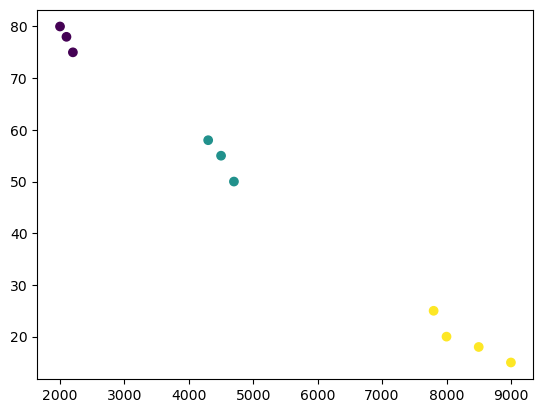

In [45]:
plt.scatter(df["Income"],df["Spending_Score"],c=labels)

In [46]:
from sklearn.cluster import AgglomerativeClustering
import scipy.cluster.hierarchy as sch

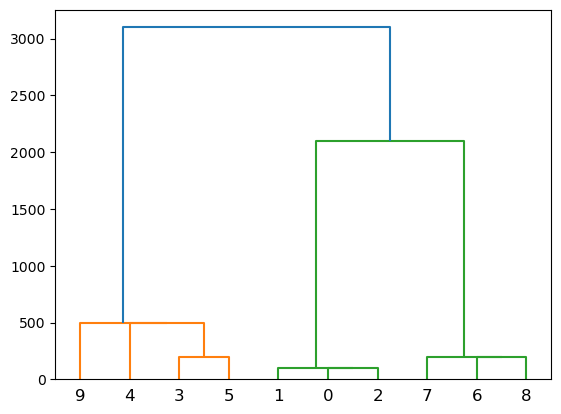

In [47]:
dendogram = sch.dendrogram(sch.linkage(x, 'single'))

In [48]:
cluster = AgglomerativeClustering(n_clusters=2,metric="euclidean",linkage="single")

In [49]:
labelsh = cluster.fit_predict(x)

In [50]:
df["cluster"] = labelsh

In [51]:
df

,Age,Income,Spending_Score,cluster
0,22,2000,80,0
1,25,2200,75,0
2,23,2100,78,0
3,45,8000,20,1
4,47,8500,18,1
5,43,7800,25,1
6,31,4500,55,0
7,33,4700,50,0
8,30,4300,58,0
9,52,9000,15,1
